Introducción a las bases de la Astronomía Estelar
===

Autores
---
J.P. Calderón & R. Gamen

Resumen
---
La astronomía es una Ciencia cuya fuente de información principal es la radiación que nos llega de las estrellas y demás objetos celestes. El objetivo de esta práctica es familiarizar al estudiante con los modelos más simples para describir la radiación estelar.

El cuerpo negro y sus aproximaciones
---
Un cuerpo negro es una entidad física ideal que absorbe toda la
radiación incidente, en todas las longitudes de onda y ángulos de
incidencia posibles. Hacia comienzos de 1900, hubieron varios intentos
de describir el espectro de radiación de un cuerpo negro, hasta que
Planck desarrolló la siguiente expresión:

\begin{equation}
%  B(\nu ,T) = \frac{2
  %    h\nu^{3}}{c^2}\frac{1}{e^{\frac{h\nu}{kT}}-1}\textnormal{.}
  B(\lambda ,T) = \frac{2 h c^{2}}{\lambda^{5}}\frac{1}{e^{\frac{h
        c}{\lambda kT}}-1}
\end{equation}

La cual describe la distribución espectral de la radiación de un
cuerpo negro, en equilibrio termodinámico, a una temperatura
$T$. Dónde $h$ y $k$ son las constantes de Planck y de Boltzmann,
respectivamente, y $c$ es la velocidad de la luz en el vacío.

La distribución de Planck, suele escribirse en terminos de $c_{1}$ y
$c_{2}$, como sigue:

\begin{equation}
  B(\lambda ,T) = \frac{c1}{\lambda^{5}}\frac{1}{e^{\frac{c2}{\lambda
        T}}-1}
\end{equation}

dónde $c_{1} = 2\,h\,c^{2}$ y $c_{2} = h c/k$. Por otro lado, aplicando la
conservación del flujo para todo el espectro, se puede transformar a
frecuencia ($\nu$),

\begin{equation}
B(\nu ,T) d\nu = -B(\lambda ,T) d\lambda
\end{equation}

teniendo en cuenta que: $d\nu = -c/\lambda^{2} d\lambda$.

Caracterización del cuerpo negro
---
El flujo irradiado por un cuerpo negro, por unidad de frecuencia, se
puede escribir de la siguiente forma:

\begin{equation}
 F(\nu) = \int B({\nu},T) \cos(\theta) d\Omega
\end{equation}

donde la integral se hace sobre el ángulo sólido $d\Omega$. Debido a
la isotropía del problema, se tiene $F(\nu)=\pi\ B(\nu,T)$. Luego,
integrando para todas las frecuencias se obtiene el flujo total
irradiado,

\begin{equation}
F = \int_{0}^{\infty} F(\nu) d\nu
\end{equation}

Por otro lado, el máximo de la distribución espectral de un cuerpo negro es inversamente proporcional a la temperatura. Esto se conoce como ley de desplazamiento de Wien,

\begin{equation}
\lambda_{\mathrm{max}} T = 0.28978~\mathrm{cm~K.}
\end{equation}

Referencias
---
* [Práctica 01 (overleaf)](https://www.overleaf.com/read/gwmxrtwffkxf)

---

Ejercicios
---

Objetivos:
* Graficar una función de planck para una temperatura determinada
* Integrar la función entre dos longitudes de onda dadas
* Evaluar las aproximaciones a la función de planck y graficarlas
* Usar la funcionalidad de manejo de unidades

**1.** Defina las funciones de Planck, Wien y Rayleigh-Jeans en la siguiente celda

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy import units as u
from astropy import constants as const
from scipy.integrate import quad

In [19]:
# Constantes en CGS via astropy — garantiza consistencia de unidades.
h  = const.h.cgs
c  = const.c.cgs
k  = const.k_B.cgs

c1 = (2 * h * c**2).to(u.erg * u.cm**2 / u.s)
c2 = (h * c / k).to(u.cm * u.K)


def B_lambda(lam_AA, T_K):
    """Planck. lam_AA en Angstrom (float/array), T_K en Kelvin (float).
    Retorna B en erg / (s cm^3)."""
    lam = (lam_AA * u.AA).to(u.cm)#.to es para cambiar la unidad
    T   = T_K * u.K
    return (c1 / lam**5 / (np.exp(c2 / (lam * T)) - 1)).to('erg / (s cm^3)')

def W_lambda(lam_AA, T_K):
    """Aproximacion de Wien. Valida en lam << lam_max."""
    lam = (lam_AA * u.AA).to(u.cm)
    T   = T_K * u.K
    return (c1 / lam**5 / np.exp(c2 / (lam * T))).to('erg / (s cm^3)')

def RJ_lambda(lam_AA, T_K):
    """Aproximacion de Rayleigh-Jeans. Valida en lam >> lam_max."""
    lam = (lam_AA * u.AA).to(u.cm)
    T   = T_K * u.K
    return (2 * c * k * T / lam**4).to('erg / (s cm^3)')

In [20]:
# Verificacion rapida: lam_max para el Sol (debe ser ~5000 AA)
T_sol = 5778  # K
lam_max_wien = (const.b_wien.cgs / (T_sol * u.K)).to(u.AA)
print(f'lambda_max (Wien, Sol): {lam_max_wien:.0f}  [esperado ~5000 AA]')

lambda_max (Wien, Sol): 5015 Angstrom  [esperado ~5000 AA]


Una vez hecho lo anterior, la siguiente celda grafica las tres funciones:

/home/vscode/.local/lib/python3.11/site-packages/astropy/units/quantity.py:648: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


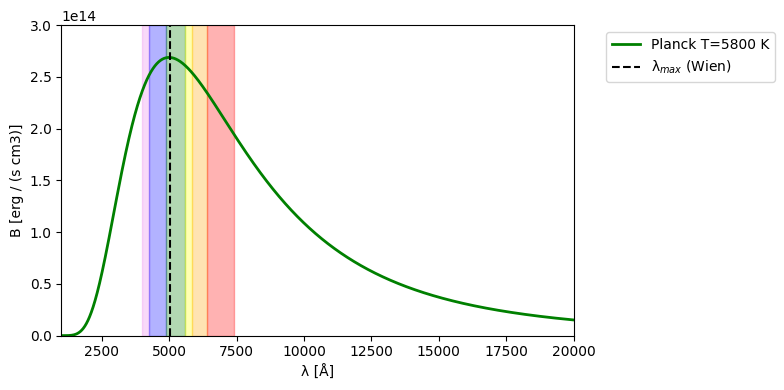

In [21]:
wav = np.arange(1E1, 1E6) # Angstroms — sin unidades, B_lambda las adjunta internamente

T = 5800 # K

B_sol = B_lambda(wav, T) # Calcula aqui para reutilizar valor y unidades

fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(8, 4), dpi=100)

ax.axvspan(4000, 4250, alpha=0.3, color='violet') # banda visible
ax.axvspan(4250, 4900, alpha=0.3, color='blue')
ax.axvspan(4900, 5600, alpha=0.3, color='green')
ax.axvspan(5600, 5850, alpha=0.3, color='yellow')
ax.axvspan(5850, 6400, alpha=0.3, color='orange')
ax.axvspan(6400, 7400, alpha=0.3, color='red')
ax.set_ylim(1E10, 1E26)# con estas dos celdas puedo modificar y correr la curva
ax.set_xlim(1E1, 1E6)

ax.set_xlabel(r"λ [Å]")
ax.set_ylabel(r"B ​[{}]".format(B_sol.unit))
ax.set_xscale('linear')
ax.set_yscale('linear')
ax.set_xlim(1000, 20000)     # Å
ax.set_ylim(0, 3e14)


ax.plot(wav, B_sol.value, color="green", linewidth=2, linestyle='-', label=f'Planck T={T} K')

ax.axvline(lam_max_wien.value, color="black", linestyle='--', label=r'λ$_{max}$ (Wien)')
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.tight_layout()
plt.show()

In [22]:
# Función auxiliar
def visible(a):
    a.axvspan ( 4000, 4250, alpha = 0.3, color = 'violet' ) 
    a.axvspan ( 4250, 4900, alpha = 0.3, color = 'blue' )
    a.axvspan ( 4900, 5600, alpha = 0.3, color = 'green' )
    a.axvspan ( 5600, 5850, alpha = 0.3, color = 'yellow' )
    a.axvspan ( 5850, 6400, alpha = 0.3, color = 'orange' )
    a.axvspan ( 6400, 7400, alpha = 0.3, color = 'red' )

**2.** La diferencia porcentual, estara dada por la diferencia de cada función respecto a la función de planck.

In [23]:
def error_pct(f_approx, f_exact):
    return np.abs((f_approx - f_exact) / f_exact) * 100

In [33]:
T = 30000
label = f'T={T} K (tipo G)'

In [34]:
lam_plot = np.logspace(2, 6, 2000)  # 100 AA a 1 mm
B  = B_lambda(lam_plot, T).value
W  = W_lambda(lam_plot, T).value
RJ = RJ_lambda(lam_plot, T).value


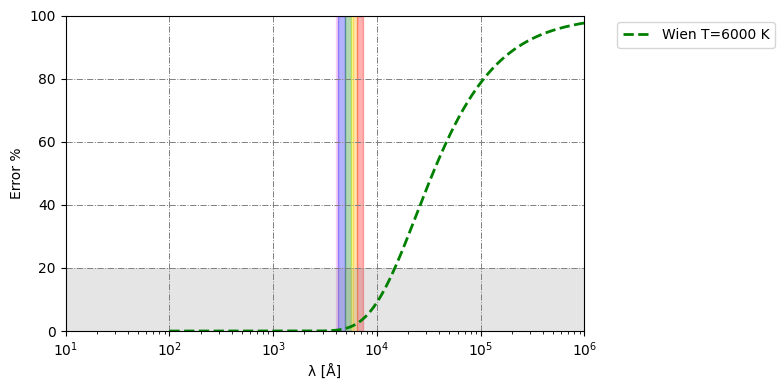

In [26]:
fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (8,4), dpi = 100 )
visible(ax) # banda vertical

ax.set_ylim ( 0., 100. )
ax.set_xlim(1E1, 1E6)

ax.set_xlabel(r"λ [Å]")
ax.set_ylabel('Error %')
ax.set_xscale ( 'log' )

ax.plot ( lam_plot, error_pct(W, B), color = "green", linewidth = 2, linestyle = '--', 
         label = 'Wien T=%i K' %T )

ax.grid ( color = 'gray', linestyle = '-.', linewidth = 0.7 )
ax.axhspan ( 0, 20, facecolor = "gray", alpha = 0.2 )

plt.legend ( bbox_to_anchor = (1.05, 1.0), loc = 'upper left' )
plt.tight_layout()
plt.show()

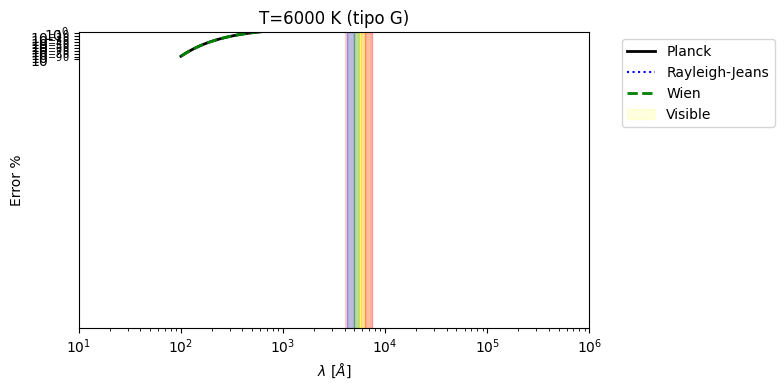

In [27]:
fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (8,4), dpi = 100 )
visible(ax) # banda vertical
ax.set_xlim(1E1, 1E6)
ax.set_ylim ( 0., 100. )

ax.loglog(lam_plot, B,  'k-',  lw=2,   label='Planck')
ax.loglog(lam_plot, RJ, 'b:',  lw=1.5, label='Rayleigh-Jeans')
ax.loglog(lam_plot, W,  'g--', lw=2, label='Wien')
ax.axvspan(4000, 7000, alpha=0.12, color='yellow', label='Visible')
ax.set_title(label)
ax.set_xlabel(r'$\lambda$ [$\AA$]')
ax.set_ylabel('Error %')
ax.legend(fontsize=9)

plt.legend ( bbox_to_anchor = (1.05, 1.0), loc = 'upper left' )
plt.tight_layout()
plt.show()

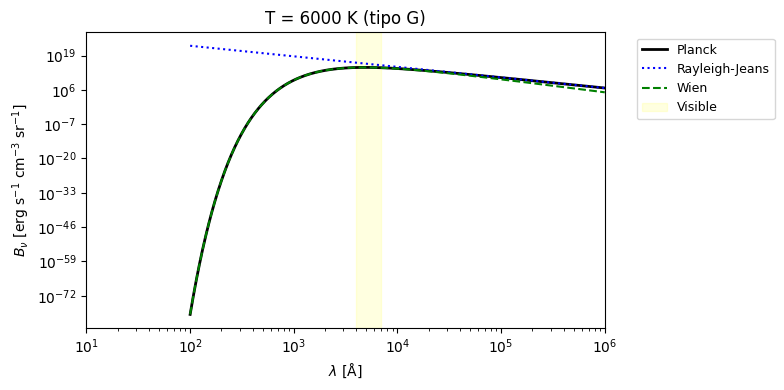

In [28]:


# Suponiendo que ya tienes definidas:
# lam_plot, B_planck(lam, T), B_RJ(lam, T), B_wien(lam, T)

T = 6000  # Temperatura en K

fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(8, 4), dpi=100)

ax.set_xlim(1e1, 1e6)

# Curvas originales
ax.loglog(lam_plot, B, 'k-', lw=2, label='Planck')
ax.loglog(lam_plot, RJ, 'b:', lw=1.5, label='Rayleigh-Jeans')

# Curva de Wien agregada
ax.loglog(lam_plot, W, 'g--', lw=1.5, label='Wien')

# Banda visible
ax.axvspan(4000, 7000, alpha=0.12, color='yellow', label='Visible')

# Etiquetas y título
ax.set_title(f'T = {T} K (tipo G)')
ax.set_xlabel(r'$\lambda$ [Å]')
ax.set_ylabel(r'$B_{\nu}$ [erg s$^{-1}$ cm$^{-3}$ sr$^{-1}$]')

# Leyenda
ax.legend(fontsize=9, bbox_to_anchor=(1.05, 1.0), loc='upper left')

plt.tight_layout()
plt.show()


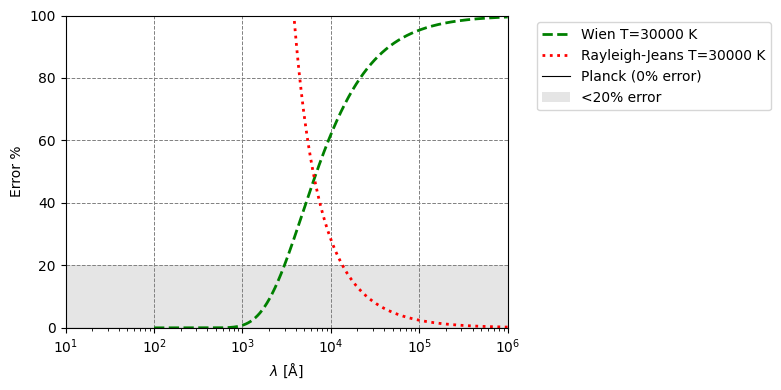

In [35]:

# Suponiendo que ya tienes definidas tus funciones:
# def error_pct_Wien(lam, T): ...
# def error_pct_RJ(lam, T): ...
# lam_plot = np.logspace(1, 6, 500)  # ejemplo: 10^1 a 10^6 Å

T = 30000  # Temperatura en K

# Crear la figura
fig, ax = plt.subplots(figsize=(8, 4), dpi=100)

# Configurar ejes
ax.set_xlim(1e1, 1e6)
ax.set_ylim(0, 100)
ax.set_xscale('log')
ax.set_xlabel(r'$\lambda$ [Å]')
ax.set_ylabel('Error %')

# Graficar las tres curvas
ax.plot(lam_plot, error_pct(W, B), 
        color="green", linewidth=2, linestyle='--', 
        label=f'Wien T={T} K')

ax.plot(lam_plot, error_pct(RJ, B), 
        color="red", linewidth=2, linestyle=':', 
        label=f'Rayleigh-Jeans T={T} K')

# Línea de referencia en 0% de error (Planck consigo misma)
ax.axhline(0, color='black', linewidth=0.8, linestyle='-', label='Planck (0% error)')

# Grilla y banda de tolerancia (0-20%)
ax.grid(color='gray', linestyle='--', linewidth=0.7)
ax.axhspan(0, 20, facecolor="gray", alpha=0.2, label='<20% error')

# Leyenda y layout
ax.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.tight_layout()
plt.show()

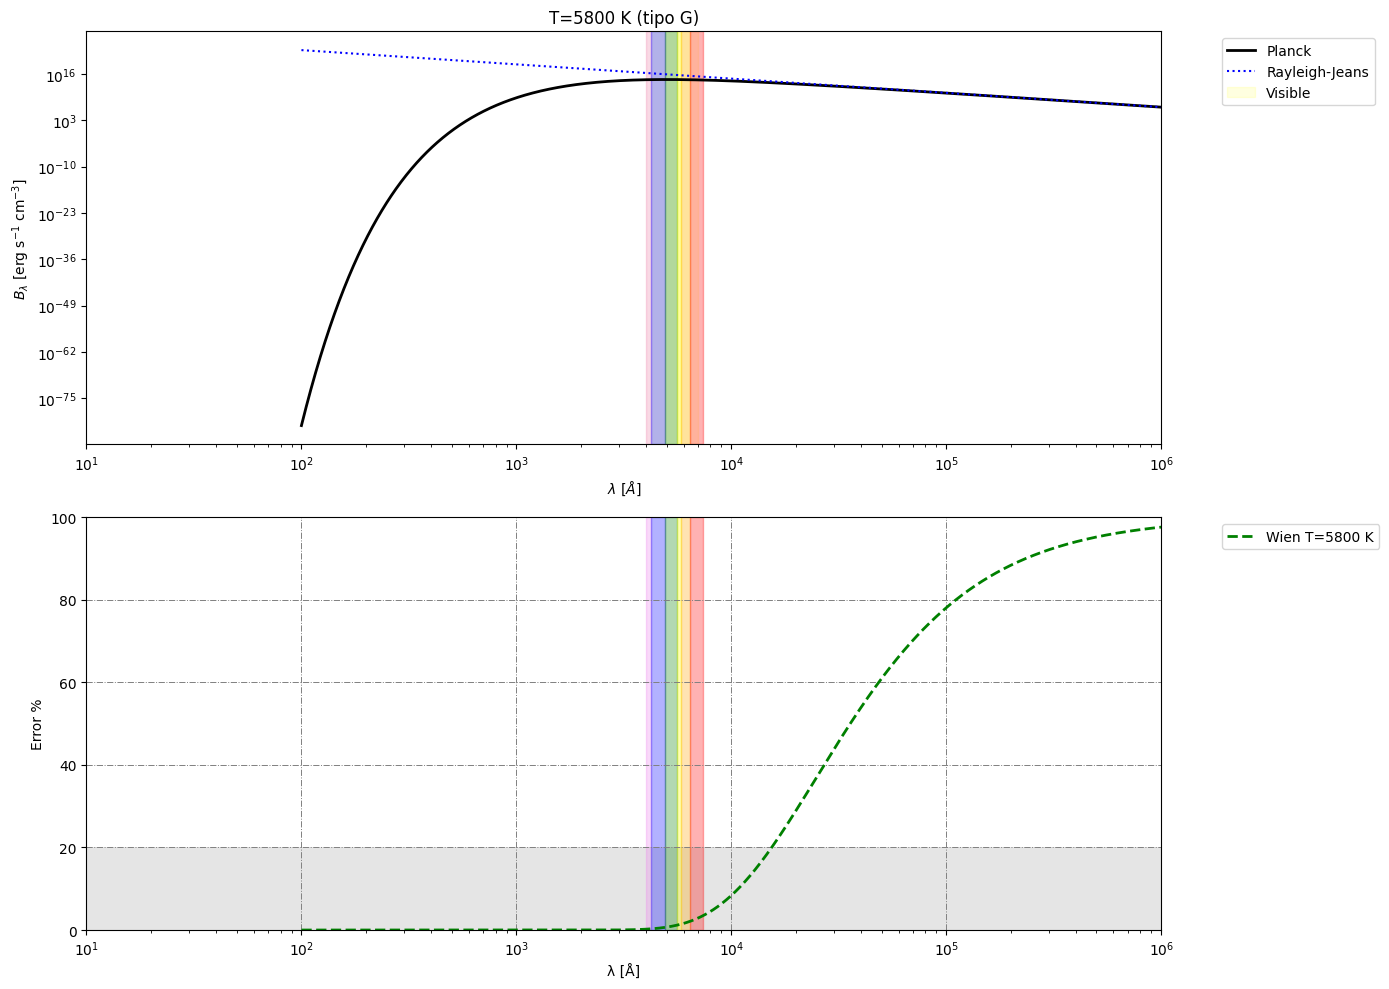

In [17]:
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(14, 10), dpi=100)

ax0.loglog(lam_plot, B,  'k-',  lw=2,   label='Planck')
ax0.loglog(lam_plot, RJ, 'b:',  lw=1.5, label='Rayleigh-Jeans')
ax0.axvspan(4000, 7000, alpha=0.12, color='yellow', label='Visible')
ax0.set_title(label)
ax0.set_xlabel(r'$\lambda$ [$\AA$]')
ax0.set_ylabel(r'$B_\lambda$ [erg s$^{-1}$ cm$^{-3}$]')
ax0.legend(fontsize=9)

ax1.set_ylim ( 0., 100. )
ax1.set_xlim(1E1, 1E6)

ax1.set_xlabel(r"λ [Å]")
ax1.set_ylabel('Error %')
ax1.set_xscale ( 'log' )

ax1.plot ( lam_plot, error_pct(W, B), color = "green", linewidth = 2, linestyle = '--', 
         label = 'Wien T=%i K' %T )

ax1.grid ( color = 'gray', linestyle = '-.', linewidth = 0.7 )
ax1.axhspan ( 0, 20, facecolor = "gray", alpha = 0.2 )

for ax in (ax0, ax1):
    ax.legend ( bbox_to_anchor = (1.05, 1.0), loc = 'upper left' )
    visible(ax) 
    ax.set_xlim(1E1, 1E6)

plt.tight_layout()
plt.show()

**3.** Cómo integrar una función

In [18]:
sigma = #editame
print (sigma)

SyntaxError: invalid syntax (298772535.py, line 1)

In [1]:
from scipy.integrate import quad

# Redefino la funcion para no usar unidades y multiplico por pi por la integral
# en el angulo sólido
def bb(x):
    ''' Redefino la función para que tome la long. de onda en AA 
    y con el .value le saco las unidades para poder hacer la integral.
    Además, le agrego el pi para que represente el Flujo integrado.'''
    return np.pi * B(x * u.AA, Temp).value

Temp = 5800 * u.K

# Recuerde que para calcular la integral entre 4000 y 7000AA se puede usar 
#  la función interna de python _quad_.
int, err = quad ( bb, 4000, 7000 )

# Y para el Flujo total tiene la Ley de Boltzmann. En este caso, tener en cuenta
#  las unidades (lineales) del diferencial de long. de onda.

NameError: name 'u' is not defined

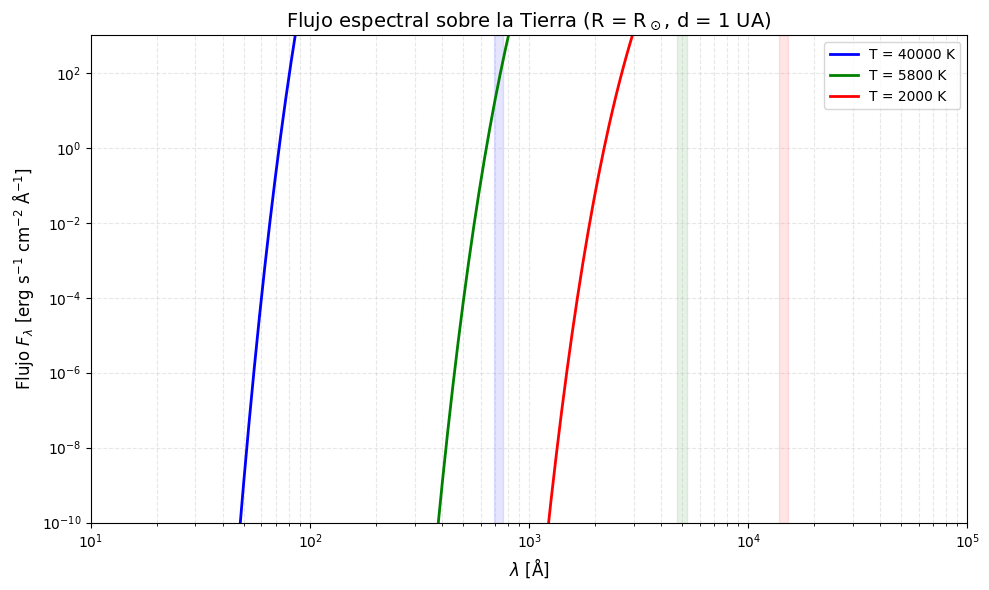

In [3]:


# Constantes en cgs
h = 6.626e-27      # erg·s
c = 2.998e10       # cm/s
k_B = 1.381e-16    # erg/K
R_sun = 6.96e10    # cm
AU = 1.496e13      # cm

# Factor geométrico (R/d)^2
geom_factor = (R_sun / AU)**2

def B_lambda(lam, T):
    """Intensidad específica de Planck en erg s^-1 cm^-3 sr^-1"""
    lam_cm = lam * 1e-8  # convertir Å a cm
    x = (h * c) / (lam_cm * k_B * T)
    # Evitar overflow
    x = np.clip(x, 1e-10, 100)
    return (2 * h * c**2) / (lam_cm**5) / (np.exp(x) - 1)

def flujo_espectral(lam, T):
    """Flujo sobre la Tierra en erg s^-1 cm^-2 Å^-1"""
    return geom_factor * np.pi * B_lambda(lam, T)

# Temperaturas
T_vals = [40000, 5800, 2000]
labels = [f'T = {T} K' for T in T_vals]
colors = ['blue', 'green', 'red']

# Rango de longitudes de onda: cubrir máximos de todas
lam_plot = np.logspace(1, 5, 500)  # 10 a 100,000 Å

# Gráfico
fig, ax = plt.subplots(figsize=(10, 6))

for T, label, color in zip(T_vals, labels, colors):
    F = flujo_espectral(lam_plot, T)
    ax.loglog(lam_plot, F, lw=2, label=label, color=color)
    
    # Ley de Wien
    lambda_max = 2.898e7 / T  # en Å
    F_max = flujo_espectral(lambda_max, T)
    # Margen del 5%
    lambda_min = lambda_max * 0.95
    lambda_max_err = lambda_max * 1.05
    ax.plot(lambda_max, F_max, 'o', color=color, markersize=6)
    ax.axvspan(lambda_min, lambda_max_err, alpha=0.1, color=color)

# Formato
ax.set_xlim(1e1, 1e5)
ax.set_ylim(1e-10, 1e3)
ax.set_xlabel(r'$\lambda$ [Å]', fontsize=12)
ax.set_ylabel(r'Flujo $F_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]', fontsize=12)
ax.set_title('Flujo espectral sobre la Tierra (R = R$_\odot$, d = 1 UA)', fontsize=14)
ax.grid(True, which='both', linestyle='--', alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

/tmp/ipykernel_825/2661506479.py:18: RuntimeWarning: overflow encountered in exp
  return (2*h*c**2)/(lam**5) / (np.exp(h*c/(lam*k*T)) - 1)


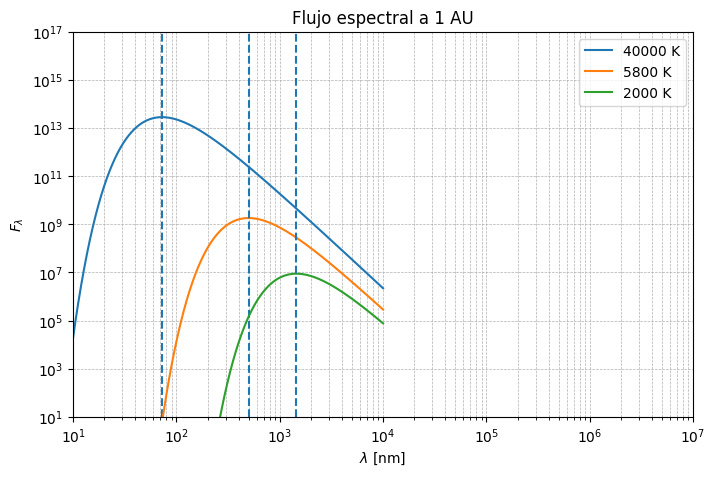

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import h, c, k

# constantes
R_sun = 6.96e8      # m
d = 1.496e11        # m (1 AU)

# temperaturas
temps = [40000, 5800, 2000]
labels = ['40000 K', '5800 K', '2000 K']


# longitudes de onda (en metros)
lam = np.logspace(-9, -5, 2000)  # 1 nm a 10 micrones

def B_lambda(lam, T):
    return (2*h*c**2)/(lam**5) / (np.exp(h*c/(lam*k*T)) - 1)

plt.figure(figsize=(8,5))

for T, lab in zip(temps, labels):
    B = B_lambda(lam, T)
    F = np.pi * B * (R_sun/d)**2
    
    plt.loglog(lam*1e9, F, label=lab)  # nm

    # máximo numérico
    lam_max = lam[np.argmax(F)]
    plt.axvline(lam_max*1e9, linestyle='--')

plt.xlabel(r'$\lambda$ [nm]')
plt.ylabel(r'$F_\lambda$')
plt.legend()
plt.title('Flujo espectral a 1 AU')
plt.grid(True, which="both", ls="--", lw=0.5)

plt.xlim(1e1, 1e7)
plt.ylim(1e1, 1e17)


plt.show()

/tmp/ipykernel_825/148350974.py:16: RuntimeWarning: overflow encountered in exp
  return (2*h*c**2)/(lam**5) / (np.exp(h*c/(lam*k*T)) - 1)


NameError: name 'ax' is not defined

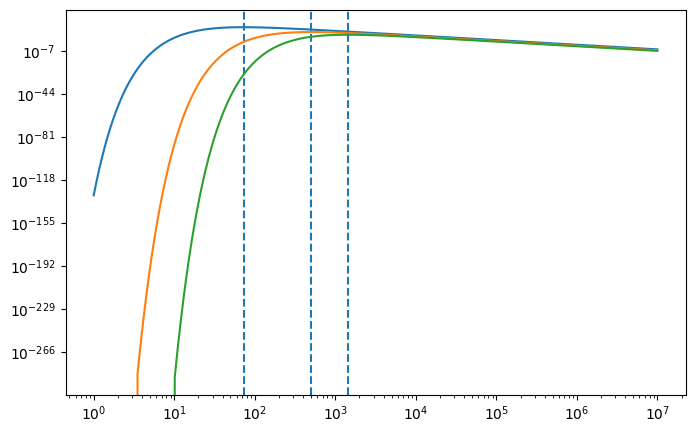

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import h, c, k

# constantes
R_sun = 6.96e8      # m
d = 1.496e11        # m (1 AU)

# temperaturas
temps = [40000, 5800, 2000]
labels = ['40000 K', '5800 K', '2000 K']

lam = np.logspace(-9, -2, 4000)   # 1 nm a 10^7 nm

def B_lambda(lam, T):
    return (2*h*c**2)/(lam**5) / (np.exp(h*c/(lam*k*T)) - 1)

plt.figure(figsize=(8,5))

for T, lab in zip(temps, labels):
    B = B_lambda(lam, T)
    F = np.pi * B * (R_sun/d)**2

    plt.loglog(lam*1e9, F, label=lab)

    # máximo
    lam_max = lam[np.argmax(F)]
    plt.axvline(lam_max*1e9, linestyle='--')

plt.xlabel(r'$\lambda$ [nm]')
plt.ylabel(r'$F_\lambda$')
plt.legend()
plt.title('Flujo espectral a 1 AU')
plt.grid(True, which="both", ls="--", lw=0.5)

# ahora sí coincide con los datos
plt.xlim(1e1, 1e6)
plt.ylim(1e1, 1e17)

plt.show()

/tmp/ipykernel_825/2968519268.py:17: RuntimeWarning: overflow encountered in exp
  return (2*h*c**2)/(lam**5) / (np.exp(h*c/(lam*k*T)) - 1)


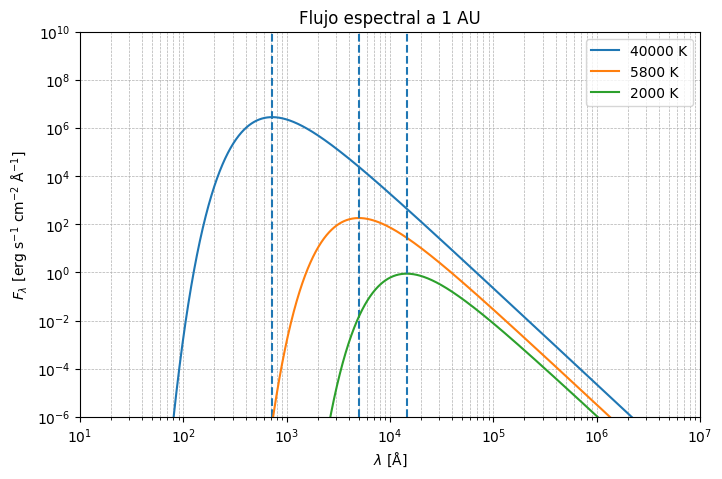

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import h, c, k

# constantes
R_sun = 6.96e8      # m
d = 1.496e11        # m (1 AU)

# temperaturas
temps = [40000, 5800, 2000]
labels = ['40000 K', '5800 K', '2000 K']

# longitudes de onda (1 nm a 10^7 nm)
lam = np.logspace(-9, -2, 4000)   # m

def B_lambda(lam, T):
    return (2*h*c**2)/(lam**5) / (np.exp(h*c/(lam*k*T)) - 1)

plt.figure(figsize=(8,5))

for T, lab in zip(temps, labels):
    B = B_lambda(lam, T)
    F = np.pi * B * (R_sun/d)**2

    # 🔁 conversión de unidades
    lam_A = lam * 1e10          # m → Å
    F = F * 1e-7                # SI → erg/(s cm^2 Å)

    plt.loglog(lam_A, F, label=lab)

    # máximo
    lam_max = lam[np.argmax(np.pi * B * (R_sun/d)**2)]
    plt.axvline(lam_max*1e10, linestyle='--')

plt.xlabel(r'$\lambda\ [\mathrm{\AA}]$')
plt.ylabel(r'$F_\lambda\ [\mathrm{erg\ s^{-1}\ cm^{-2}\ \AA^{-1}}]$')
plt.legend()
plt.title('Flujo espectral a 1 AU')
plt.grid(True, which="both", ls="--", lw=0.5)

plt.xlim(1e1, 1e7)
plt.ylim(1e-6, 1e10)

plt.show()